# Periodic Boundary Conditions

Tomamos la ecuación de poisson en el mismo intervalo:
$$\frac{d^2u}{dx^2}+\pi^2\sin(\pi x)=0,\qquad x\in[-1,1]$$

La condición de **Dirichlet** en una frontera es:
$$u(-1)=0$$

Y la condición de **Robin** en la frontera derecha:

$$u(-1)=u(1)$$


La solucíon exacta en este caso es:
$$u(x)=\sin(\pi x)$$

Estas condiciones de frontera  (Junto con la BC Robin) son tareas más críticas que aveces incluso pueden introducir inestabilidades en el entrenamiento lo que puede llebar a una solucion de la red debil.


Las condiciones de frontera periodicas implican que la solucion debe tener el mismo valor en puntos pares atravez de fronteras opuestas, creando una solucion cíclica.


### Loss en las BC es de $1e-8$
Para este preoblema es adecuado, pero hay otros problemas en que no lo es. Por ejemplo, en la eq de Burger o las eq de Navier Stokes. No es suficiente este número.



In [58]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

dde.backend.backend_name = "pytorch"

In [69]:
import torch as tr
import tensorflow as tf

In [92]:
def pde(x, y):
    dy_xx = dde.grad.hessian(y,x)
    return dy_xx + np.pi**2*tf.sin(np.pi*x)

In [93]:
## Exact solution
def func(x):
    return np.sin(np.pi*x)

### Dirichlet

In [94]:
def boundary_value1(x):
    return 0 #Sets u=0

def boundary_1(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],-1)

### Periodic

In [95]:

def boundary_r(x,on_boundary):
    return on_boundary and dde.utils.isclose(x[0],1)

### Main PINN Model

In [96]:
geom = dde.geometry.Interval(-1,1)

In [97]:
bc_1=dde.icbc.DirichletBC(geom, boundary_value1,boundary_1)
bc_r=dde.icbc.PeriodicBC(geom,0,boundary_r)


In [98]:
## Data model:
data = dde.data.PDE(geom,
                    pde,
                    [bc_1,bc_r],
                    16,         # No of collocation points
                    2,
                    solution=func,
                    num_test=100
                   )

In [99]:
layer_size = [1] + [50]*3 + [1]
# [1]: x input layer
# [50]*3: 3 capas ocultas con 50 neuronas
# [1]: y output layer
activation = "tanh"
initializer = "Glorot uniform"

## FNN Fully conected neural network
net = dde.nn.FNN(layer_size,
                activation,
                initializer
                )

In [102]:
model = dde.Model(data,net)

model.compile("adam",lr=1e-3,metrics=["l2 relative error"])

losshistory, train_state = model.train(iterations = 5000)

Compiling model...
'compile' took 0.008223 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [2.49e-06, 5.43e-08, 2.02e-07]    [6.04e-06, 5.43e-08, 2.02e-07]    [2.46e-04]    
1000      [2.13e-06, 1.15e-11, 5.35e-12]    [6.21e-06, 1.15e-11, 5.35e-12]    [1.94e-05]    
2000      [2.80e-06, 1.33e-07, 2.88e-07]    [7.10e-06, 1.33e-07, 2.88e-07]    [2.67e-04]    
3000      [1.68e-06, 1.86e-11, 8.66e-12]    [5.49e-06, 1.86e-11, 8.66e-12]    [1.71e-05]    
4000      [2.58e-06, 1.52e-07, 6.44e-07]    [7.42e-06, 1.52e-07, 6.44e-07]    [4.43e-04]    
5000      [4.84e-05, 4.83e-06, 1.63e-05]    [3.17e-05, 4.83e-06, 1.63e-05]    [1.70e-03]    

Best model at step 3000:
  train loss: 1.68e-06
  test loss: 5.49e-06
  test metric: [1.71e-05]

'train' took 6.793085 s



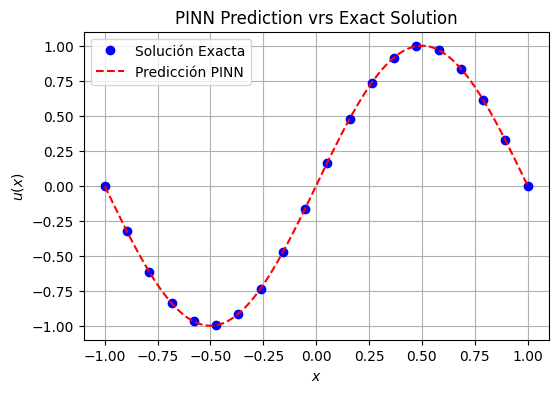

In [103]:
x_values_pinn = np.linspace(-1,1,100).reshape(-1,1)
y_pred        = model.predict(x_values_pinn)

x_values_exact = np.linspace(-1,1,20).reshape(-1,1)
y_exact        = func(x_values_exact)


plt.figure(figsize=(6,4))
plt.plot(x_values_exact,y_exact,'ob',label="Solución Exacta")

plt.plot(x_values_pinn,y_pred,'--r',label="Predicción PINN")

plt.xlabel("$x$")
plt.ylabel("$u(x)$")
plt.title("PINN Prediction vrs Exact Solution")
plt.legend()
plt.grid()
plt.show()

### Usando collocation_points 

In [105]:
X= geom.uniform_points(10) # Genera 10 puntos en el intervalo [-1,1]
X

array([[-1.        ],
       [-0.7777778 ],
       [-0.5555556 ],
       [-0.33333334],
       [-0.11111111],
       [ 0.11111111],
       [ 0.33333334],
       [ 0.5555556 ],
       [ 0.7777778 ],
       [ 1.        ]], dtype=float32)

In [107]:
periodic_points = bc_r.collocation_points(X) ## Puntos en donde se aplican las condiciones de frontera.
periodic_points

array([[ 1.],
       [-1.]], dtype=float32)

### Usando error

In [108]:
inputs  = tr.tensor(periodic_points, dtype=tr.float32)
inputs

tensor([[ 1.],
        [-1.]])

In [109]:
outputs = tr.tensor(model.predict(periodic_points), dtype=tr.float32)
outputs

tensor([[ 0.0018],
        [-0.0022]])

In [110]:
beg, end = 0, len(periodic_points)

In [112]:
residual = bc_r.error(X, inputs, outputs, beg, end)
residual

tensor([[0.0040]])

In [114]:
mse_residual = tr.mean(residual**2) # Este es el que se minimiza
print("MSE of boundary residual for periodic condition (u(-1)- u(1)):", mse_residual.item())

MSE of boundary residual for periodic condition (u(-1)- u(1)): 1.6321502698701806e-05


### Tambien se puede extraer el error de las condiciones de frontera de Dirichlet

In [127]:
X_boundary = np.array([[-1.0]])

inputs  = tr.tensor(X_boundary, dtype=tr.float32)
outputs = tr.tensor(model.predict(X_boundary),dtype=tr.float32)

beg, end = 0, len(X_boundary)

residual_left_tf = bc_1.error(X_boundary, inputs, outputs, beg, end)
residual_left    = tr.tensor(residual_left_tf.numpy(), dtype=tr.float32)


mse_residual = tr.mean(residual_left**2) # Este es el que se minimiza
print("MSE of boundary residual for Dirichlet condition:", mse_residual.item())

MSE of boundary residual for Dirichlet condition: 4.831971637031529e-06
